|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 2:</h2>|<h1>Batching<h1>|
|<h2>Section:</h2>|<h1>Continuous batching<h1>|
|<h2>Lecture:</h2>|<h1><b>What it does to the tail, and why an idle server can still be slow<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

rng = np.random.default_rng(0)

# What the scheduler does to latency

Throughput is the number in your benchmark. Latency is the number your users
feel. The two schedulers differ far more on latency.

Sweep the arrival rate from quiet to almost saturated. Watch what each
scheduler does to the tail.

In [2]:
### run this cell: a workload

NUM_REQUESTS = 3000
lengths = rng.lognormal(mean=np.log(120), sigma=0.9, size=NUM_REQUESTS).astype(int) + 1
NUM_SLOTS = 64                       # slots on the GPU

capacity = NUM_SLOTS / lengths.mean()      # requests per step, if no slot is ever idle
print(f'mean output {lengths.mean():.0f} tokens')
print(f'{NUM_SLOTS} slots -> {capacity:.3f} requests per step at best')

mean output 174 tokens
64 slots -> 0.369 requests per step at best


In [3]:
def static_batching(arrivals, lengths, NUM_SLOTS):
  """Fill a batch, run it to completion, start the next one."""
  finish_steps = np.zeros(len(lengths))
  step = 0.0
  first_waiting = 0
  while first_waiting < len(lengths):
    batch = np.arange(first_waiting, min(first_waiting+NUM_SLOTS, len(lengths)))
    step = max(step, arrivals[batch[-1]])      # wait for the batch to FILL
    steps = lengths[batch].max()           # run until the SLOWEST finishes
    finish_steps[batch] = step + steps                # everyone leaves together
    step += steps
    first_waiting += NUM_SLOTS
  return finish_steps

def continuous_batching(arrivals, lengths, NUM_SLOTS):
  """Re-decide the batch after every single step."""
  finish_steps = np.zeros(len(lengths))
  step = 0.0
  next_request = 0
  running = {}
  while next_request < len(lengths) or running:
    while len(running) < NUM_SLOTS and next_request < len(lengths) and arrivals[next_request] <= step:
      running[next_request] = lengths[next_request]
      next_request += 1  # admit into a free slot
    if not running:
      step = arrivals[next_request]
      continue  # idle, wait for work
    step += 1.0                                    # ONE decode step
    for request in list(running):
      running[request] -= 1
      if running[request] == 0:
        finish_steps[request] = step
        del running[request]  # evict the moment it ends
  return finish_steps

### The classic load curve

In [4]:
loads = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
rows = []

for load in loads:
  arrivals = np.cumsum(rng.exponential(1/(load*capacity), size=NUM_REQUESTS))
  static_latency = static_batching(arrivals, lengths, NUM_SLOTS)     - arrivals
  continuous_latency = continuous_batching(arrivals, lengths, NUM_SLOTS) - arrivals
  rows.append((load, np.median(static_latency), np.percentile(static_latency,99),
                     np.median(continuous_latency), np.percentile(continuous_latency,99)))

print(f"{'load':>6} {'static p50':>11} {'static p99':>11} {'cont p50':>10} {'cont p99':>10}")
for load_fraction,static_p50,static_p99,continuous_p50,continuous_p99 in rows:
  print(f'{load_fraction:>6.0%} {static_p50:>11,.0f} {static_p99:>11,.0f} {continuous_p50:>10,.0f} {continuous_p99:>10,.0f}')

  load  static p50  static p99   cont p50   cont p99
   10%       1,834       3,202        115        894
   20%       5,729       8,054        115        893
   30%      10,730      20,045        115        893
   40%      14,206      26,606        115        893
   50%      16,213      30,570        115        893
   60%      17,246      33,146        115        894
   70%      18,455      35,129        115        894
   80%      18,757      36,427        116        893
   90%      19,514      37,530        124        896


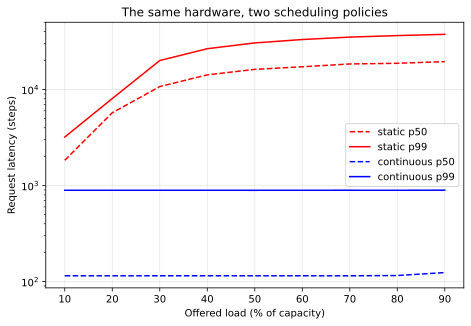

In [5]:
results = np.array(rows)

plt.figure(figsize=(7.5,4.8))
plt.plot(100*results[:,0], results[:,1], 'r--', label='static p50')
plt.plot(100*results[:,0], results[:,2], 'r-',  label='static p99')
plt.plot(100*results[:,0], results[:,3], 'b--', label='continuous p50')
plt.plot(100*results[:,0], results[:,4], 'b-',  label='continuous p99')
plt.yscale('log')
plt.xlabel('Offered load (% of capacity)')
plt.ylabel('Request latency (steps)')
plt.title('The same hardware, two scheduling policies')
plt.legend()
plt.grid(alpha=.3)
plt.show()

### Read the two shapes

**The continuous lines are flat.** Latency hardly moves from 10 percent load
to 90 percent. A system with spare capacity looks like this. Work arrives, a
slot is free, and the work starts at once.

**The static lines are high everywhere, including at 10 percent load.** Look
hard at that. At 10 percent load the machine is almost idle, and a request
still waits tens of thousands of steps.

The request does not wait for the GPU. It waits for **63 other requests to
arrive**. A static batch cannot start until it is full. The first request in a
batch pays the arrival time of the last one.

So static batching does more than waste throughput. It turns an idle machine
into a slow one. That is the worst trade in serving.

### What this costs in a real system

A serving team reports two numbers:

- **TTFT**, the time to first token. Under static batching it includes the
  wait for the batch to fill. Under continuous batching it is a prefill.
- **Goodput**, the throughput that met its latency target. Static batching can
  show good throughput and almost no goodput. A throughput benchmark hides
  this.

Stage 16 makes you measure both correctly. Stage 10 handles the next problem.
Continuous batching succeeds, you run out of KV memory during a step, and you
must take a slot back.

    ./vc guide 16